# Augmentations

In [1]:
import os
import time
from pathlib import Path

root = Path.cwd()
print(root)
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

import zarr
import tifffile
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.ndimage import rotate

/scratch/wmz2007/neuroinfo_fruitfly/ipynb
/scratch/wmz2007/neuroinfo_fruitfly


## Helper Functions

### Imaging

In [2]:
def gen_mip(raw, axis) -> np.ndarray:
    """Max-intensity projection of RGB channels. For CZYX: axis=1 is the z projection."""
    mip = raw.astype(np.float32).max(axis=axis)
    mip = (mip - mip.min()) / (np.ptp(mip) + 1e-8)
    return np.moveaxis(mip, 0, -1)  # (Y, X, C)

In [3]:
PCT_LOW, PCT_HIGH, GAMMA = 1.0, 99.5, 0.72
def enhance_display(data: np.ndarray) -> np.ndarray:
    """Shared contrast + gamma; same defaults as web/server/services/volume_pipeline.py."""
    v = data.astype(np.float32)
    if not np.any(v > 0):
        return np.zeros_like(v)
    sample = v[v > 0] if np.count_nonzero(v) > 256 else v.ravel()
    lo, hi = np.percentile(sample, [PCT_LOW, PCT_HIGH])
    if hi <= lo:
        lo, hi = float(v.min()), float(v.max())
    if hi <= lo:
        return np.zeros_like(v)
    return np.clip((v - lo) / (hi - lo), 0, 1) ** GAMMA
def fisbe_rgb_mip(raw_czyx, z_axis=1) -> np.ndarray:
    """raw: CZYX. Returns Y×X×3 uint8, web-matched vibrance."""
    c = min(raw_czyx.shape[0], 3)
    mip_cyx = np.asarray(raw_czyx[:c], dtype=np.float32).max(axis=z_axis)  # C,Y,X
    rgb01 = enhance_display(mip_cyx)  # shared stretch across channels (keeps hue)
    return np.moveaxis((rgb01 * 255).astype(np.uint8), 0, -1)

### Stats

In [ ]:
def per_channel_stats(data):
    

## Base Image

### BiaPy Pre - Processing

In [4]:
SAMPLE_ID = "JRC_SS04989-20160318_24_A2"
path = root / f"fisbe/biapy-no-aug/test/raw/{SAMPLE_ID}.tif"
img = tifffile.imread(path)
img = np.moveaxis(img, 0, 1)  # BiaPy ZCYX -> CZYX
print(path)
print(img.shape, img.dtype)

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-no-aug/test/raw/JRC_SS04989-20160318_24_A2.tif
(3, 390, 680, 680) uint16


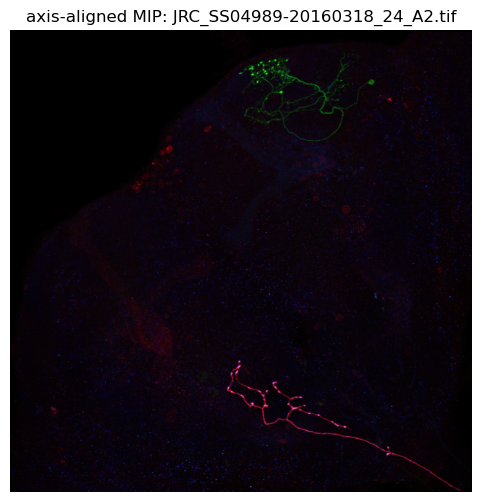

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(gen_mip(img, 1))
plt.axis("off")
plt.title(f"axis-aligned MIP: {path.name}")
plt.show()

### Original Fisbe Image

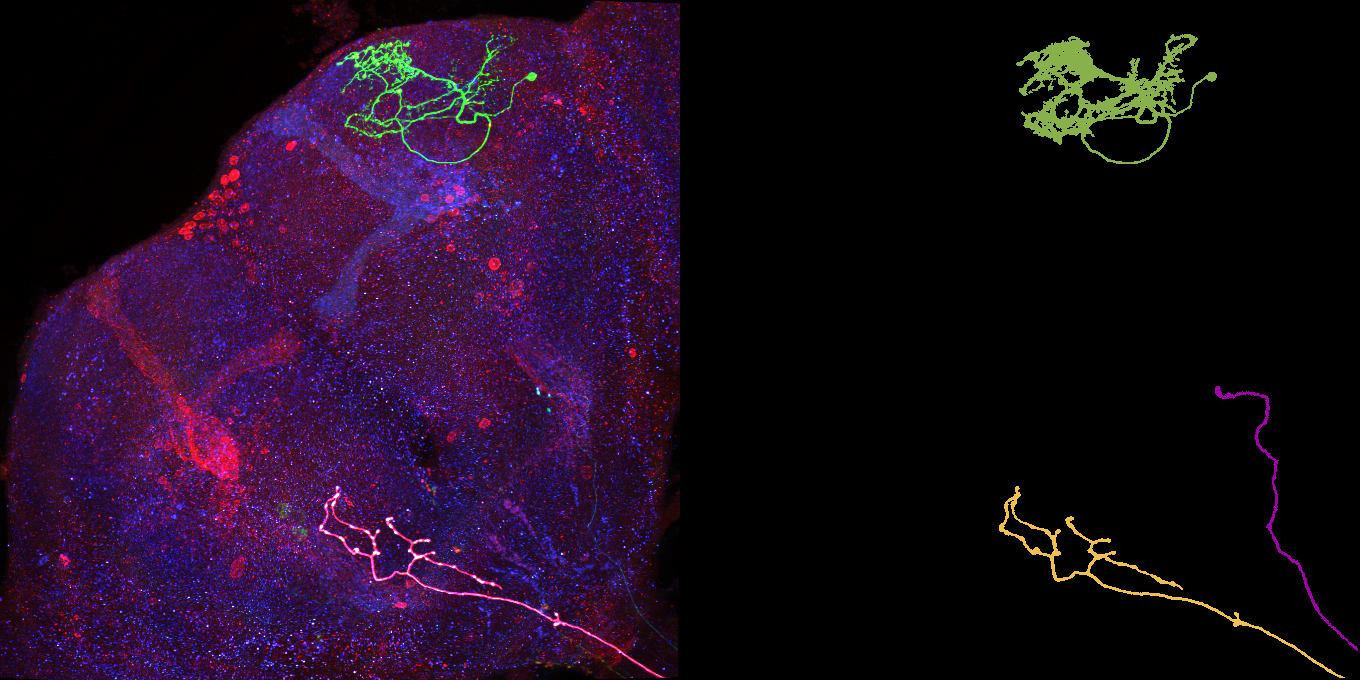

In [6]:
from IPython.display import Image, display
ORIGINAL_MIP = Path("fisbe/mips/completely/test")
display(Image(filename=(ORIGINAL_MIP / f"{SAMPLE_ID}.png").as_posix()))

### Original Fisbe Data, Custom Visualization

raw Shape: (3, 390, 680, 680)
rgb Shape: (680, 680, 3)


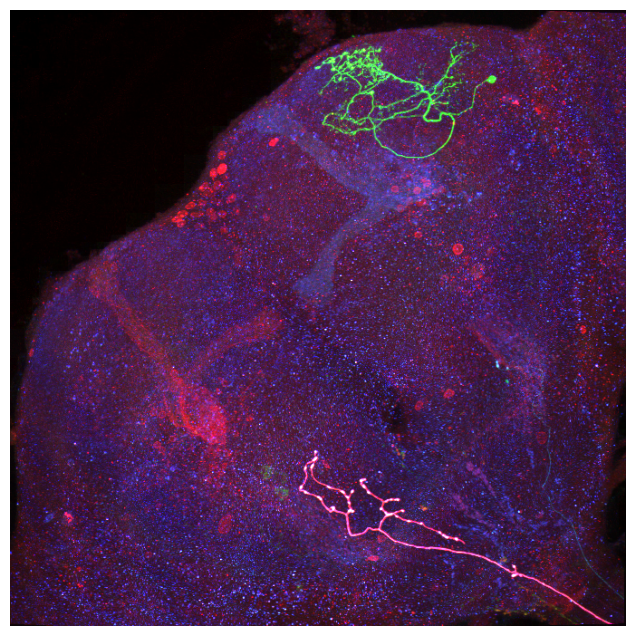

In [ ]:
# Use volumes/raw (not raw_normalized)
raw = zarr.open(f"fisbe/completely/test/{SAMPLE_ID}.zarr", mode="r", path="volumes/raw")
print(f"raw Shape: {raw.shape}")
rgb = fisbe_rgb_mip(raw)  # for in-memory array: fisbe_rgb_mip(np.asarray(raw))
print(f"rgb Shape: {rgb.shape}")
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()

## Applied Augmentation

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

AUG_DATA_DIR = root / "fisbe/biapy-debug/test/raw"
sample_augmentations = sorted(AUG_DATA_DIR.glob("JRC_SS04989-20160318_24_A2*"))
print(len(sample_augmentations))


def load_mip(path: Path):
    img = tifffile.imread(path)
    img = np.moveaxis(img, 0, 1)  # BiaPy ZCYX -> CZYX
    return path, fisbe_rgb_mip(img, 1)


mips = []
with ThreadPoolExecutor(max_workers=2) as ex:
    futures = {ex.submit(load_mip, p): i for i, p in enumerate(sample_augmentations)}
    for fut in tqdm(as_completed(futures), total=len(futures)):
        i = futures[fut]
        mips.append(fut.result())

for chunk_start in range(0, len(mips), 4):
    chunk = mips[chunk_start : chunk_start + 4]
    fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=150)
    for i, (path, mip) in enumerate(chunk):
        ax = axes[i // 2, i % 2]
        ax.imshow(mip)
        ax.set_title(path.stem.replace("R38F04-20181005_63_G3", ""), fontsize=8)
        ax.axis("off")
    plt.tight_layout(pad=0.2, w_pad=0.1, h_pad=0.2)
    plt.show()



## Weighting Channels

In [ ]:
DATA_DIR = root / "fisbe/biapy-data_channel-rot/test/raw"
# JRC_SS04989-20160318_24_A2